In [118]:
import pandas as pd
import numpy as np 
from sklearn.naive_bayes import MultinomialNB # softmax nb
from sklearn.model_selection import train_test_split
from  sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve,auc,log_loss,accuracy_score, confusion_matrix
from sklearn.calibration import calibration_curve



In [119]:
df =  pd.read_csv('spam.csv',encoding='latin-1', )[['v1','v2']]
df.columns = ['label','text']
df['label'] = df['label'].map({'ham': 0,'spam':1 })

In [120]:
df.head(3)

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...


In [121]:
df.info

<bound method DataFrame.info of       label                                               text
0         0  Go until jurong point, crazy.. Available only ...
1         0                      Ok lar... Joking wif u oni...
2         1  Free entry in 2 a wkly comp to win FA Cup fina...
3         0  U dun say so early hor... U c already then say...
4         0  Nah I don't think he goes to usf, he lives aro...
...     ...                                                ...
5567      1  This is the 2nd time we have tried 2 contact u...
5568      0              Will Ì_ b going to esplanade fr home?
5569      0  Pity, * was in mood for that. So...any other s...
5570      0  The guy did some bitching but I acted like i'd...
5571      0                         Rofl. Its true to its name

[5572 rows x 2 columns]>

In [122]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
x = vectorizer.fit_transform(df.text)
y = df.label
x.shape,y.shape

((5572, 8672), (5572,))

In [123]:
x

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 73916 stored elements and shape (5572, 8672)>

In [124]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape 

((4457, 8672), (1115, 8672), (4457,), (1115,))

In [125]:
mnb = MultinomialNB()
lor = LogisticRegression(max_iter = 3000)

In [126]:
mnb.fit(x_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [127]:
lor.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [128]:
y_pred_mnb = mnb.predict(x_test)
acc = accuracy_score(y_test,y_pred_mnb)

y_pred_mnb_proba = mnb.predict_proba(x_test)[:,1]
log_loss_score = log_loss(y_test,y_pred_mnb_proba)
confusion_matrix_mat  = confusion_matrix(y_test,y_pred_mnb)

print("Accuracy score",acc)
print("Log loss ",log_loss_score)
print("Confusion matrix",confusion_matrix_mat)


Accuracy score 0.97847533632287
Log loss  0.13057997273513913
Confusion matrix [[952  13]
 [ 11 139]]


In [129]:
y_pred_lor = lor.predict(x_test)
acc = accuracy_score(y_test,y_pred_lor)

y_pred_lor_proba = lor.predict_proba(x_test)[:,1]
log_loss_score = log_loss(y_test,y_pred_lor_proba)
confusion_matrix_score  = confusion_matrix(y_test,y_pred_lor)

print("Accuracy score",acc)
print("Log loss ",log_loss_score)
print("Confusion matrix",confusion_matrix_score)


Accuracy score 0.9775784753363229
Log loss  0.07231187630092374
Confusion matrix [[964   1]
 [ 24 126]]


In [130]:
from sklearn.metrics import classification_report
print ("MNB")
print(classification_report(y_test, y_pred_mnb))
print ("LOR")
print(classification_report(y_test, y_pred_lor))

MNB
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.91      0.93      0.92       150

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115

LOR
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.84      0.91       150

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115





---

# 🔥 How Calibration Helps in Classification (Core Idea)

> Classification = applying a **threshold on probability**

[
\hat{y} =
\begin{cases}
1 & \text{if } p \geq \text{threshold} \
0 & \text{otherwise}
\end{cases}
]

👉 Usually threshold = **0.5**

---

# 🔍 Where Calibration Comes In

If probabilities are **wrong**, then:

👉 your threshold decisions are also wrong

---

# ❌ Case 1: Uncalibrated Model (Naive Bayes type)

Suppose:

| True Situation | Model Prediction |
| -------------- | ---------------- |
| Should be 1    | predicts 0.6     |
| Should be 1    | predicts 0.55    |
| Should be 1    | predicts 0.52    |

Now with threshold = 0.5:
👉 classified as 1 ✅ (fine)

BUT…

---

### Problem appears when threshold changes

Say you want **high confidence classification**:

```text
threshold = 0.7
```

👉 Now ALL become 0 ❌
👉 You miss all positives

---

# ✅ Case 2: Calibrated Model

Same samples after calibration:

| True Situation | Calibrated Prediction |
| -------------- | --------------------- |
| Should be 1    | 0.8                   |
| Should be 1    | 0.75                  |
| Should be 1    | 0.72                  |

Now with threshold = 0.7:
👉 classified correctly ✅

---

# 🔥 Key Insight

> Calibration makes threshold-based classification **reliable**

---

# 🔹 5 Ways Calibration Helps Classification

## 1. Better Threshold Selection

Without calibration:

```text
0.7 threshold = meaningless
```

With calibration:

```text
0.7 = actually 70% confidence
```

👉 You can **tune thresholds properly**

---

## 2. Improves Precision–Recall Tradeoff

In classification:

* Increase threshold → higher precision
* Decrease threshold → higher recall

👉 But this only works if probabilities are **trustworthy**

---

## 3. Reduces Wrong High-Confidence Errors

Worst case in classification:

> Model is VERY confident but WRONG

Example:

* Predicts 0.99 → actually class 0

👉 Calibration reduces such errors

---

## 4. Helps in Imbalanced Data

In spam detection:

* Spam is rare

👉 You might use:

```text
threshold = 0.8
```

If model is not calibrated:

* This threshold becomes useless

---

## 5. Enables Risk-Based Decisions

Instead of:

```text
predict 0 or 1
```

You can do:

```text
if p > 0.9 → auto classify
if 0.6 < p < 0.9 → manual review
```

👉 This only works if probabilities are calibrated

---

# 🔥 Why This Matters in YOUR Project

You observed:

* Multinomial Naive Bayes
  → better recall (catches spam)

* Logistic Regression
  → better log loss (better calibration)

---

## Interpretation

### Naive Bayes

* Good at classification at **fixed threshold (0.5)**
* Bad when:

  * threshold changes
  * probability-based decisions needed

---

### Logistic Regression

* Slightly worse recall
* But:

  * reliable probabilities
  * better threshold control

---

# 🔥 Real-World Example

## Spam Filter

### Without calibration

* threshold = 0.9
  👉 many real spam missed ❌

---

### With calibration

* threshold = 0.9
  👉 only high-confidence spam blocked ✅

---

# 🧠 Final Mental Model

Think of classification like this:

* Model gives **score (probability)**
* You convert score → decision using threshold

👉 If score is wrong → decision is wrong

---

# 🔥 One-line Answer (use this anywhere)

> “Calibration improves classification by ensuring that probability thresholds correspond to true confidence levels, enabling better decision boundaries and more reliable precision–recall trade-offs.”





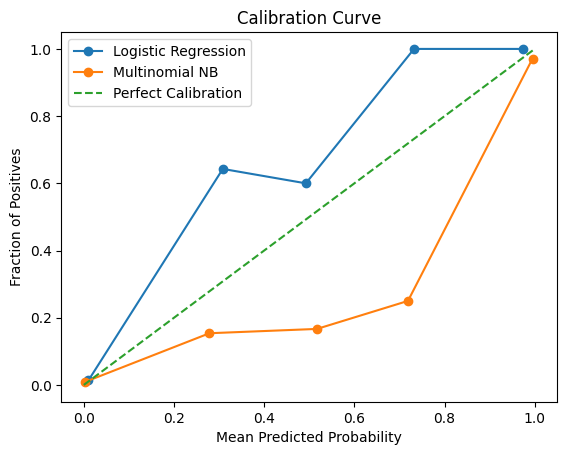

In [131]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# ALWAYS start from original model output
lor_probs = lor.predict_proba(x_test)[:, 1]
mnb_probs = mnb.predict_proba(x_test)[:, 1]

# Compute calibration curves
lr_true, lr_pred = calibration_curve(y_test, lor_probs, n_bins=5)
mnb_true, mnb_pred = calibration_curve(y_test, mnb_probs, n_bins=5)

# Plot
plt.plot(lr_pred, lr_true, marker='o', label='Logistic Regression')
plt.plot(mnb_pred, mnb_true, marker='o', label='Multinomial NB')

plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.show()

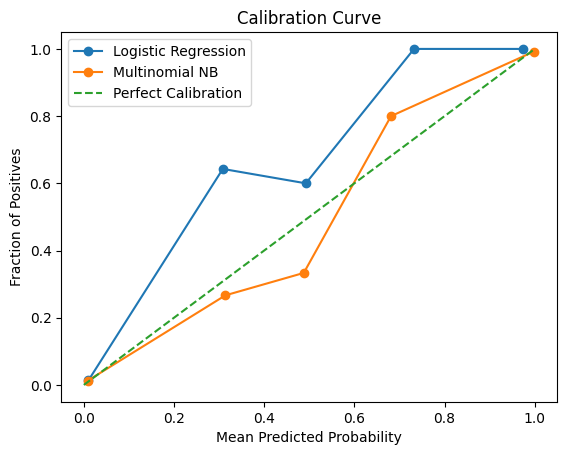

In [132]:
from sklearn.calibration import CalibratedClassifierCV

cal_nb = CalibratedClassifierCV(mnb, method='isotonic')
cal_nb.fit(x_train, y_train)

cal_nb_probs = cal_nb.predict_proba(x_test)[:,1]

lr_true, lr_pred = calibration_curve(y_test, lor_probs, n_bins=5)
mnb_true, mnb_pred = calibration_curve(y_test, cal_nb_probs, n_bins=5)

# Plot
plt.plot(lr_pred, lr_true, marker='o', label='Logistic Regression')
plt.plot(mnb_pred, mnb_true, marker='o', label='Multinomial NB')

plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.show()

In [133]:
log_loss_score = log_loss(y_test,cal_nb_probs)
print("Log loss ",log_loss_score)
log_loss_score = log_loss(y_test,y_pred_lor_proba)
print("Log loss ",log_loss_score)

Log loss  0.1518366964337317
Log loss  0.07231187630092374


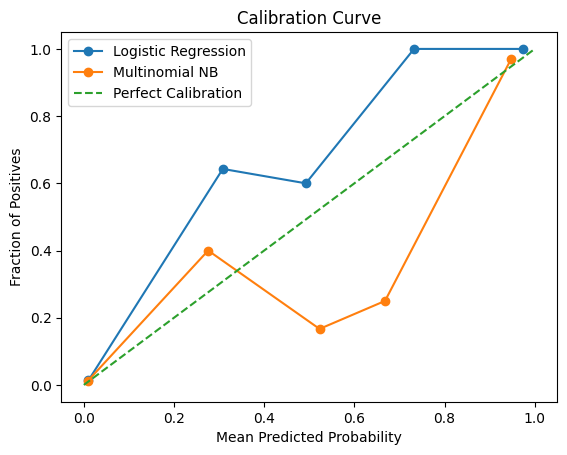

In [134]:
from sklearn.calibration import CalibratedClassifierCV

cal_nb = CalibratedClassifierCV(mnb, method='sigmoid')
cal_nb.fit(x_train, y_train)

cal_nb_probs = cal_nb.predict_proba(x_test)[:,1]

lr_true, lr_pred = calibration_curve(y_test, lor_probs, n_bins=5)
mnb_true, mnb_pred = calibration_curve(y_test, cal_nb_probs, n_bins=5)

# Plot
plt.plot(lr_pred, lr_true, marker='o', label='Logistic Regression')
plt.plot(mnb_pred, mnb_true, marker='o', label='Multinomial NB')

plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.show()

In [135]:
log_loss_score = log_loss(y_test,cal_nb_probs)
print("Log loss ",log_loss_score)
log_loss_score = log_loss(y_test,y_pred_lor_proba)
print("Log loss ",log_loss_score)

Log loss  0.07981216879210756
Log loss  0.07231187630092374


# Inference the sigmoid callibration improved the probability estimates. Which reduced the log loss as compared to isotonic which requires big datasets